In [10]:
# load relevant libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# load the weekly interval df
weekly_sentiments = pd.read_csv("../01_data/clean_labelled_data/weekly_sentiment_scores.csv")

In [15]:
# reduce the df to the relevant parties and make a copy
weekly_sentiments_subset = weekly_sentiments[
    weekly_sentiments["faction"].isin(["SPD", "Grünen", "Die LINKE"])
].copy()

# convert week column to datetime
weekly_sentiments_subset["week_start"] = pd.to_datetime(weekly_sentiments_subset["week_start"])

# remove period of the caretaker government
weekly_sentiments_subset = weekly_sentiments_subset[
    (weekly_sentiments_subset["week_start"] <= "2025-02-23") | 
    (weekly_sentiments_subset["week_start"] >= "2025-03-25")
]

# add column marking the electoral period
weekly_sentiments_subset["period"] = pd.cut(
    weekly_sentiments_subset["week_start"],
    bins=[
        pd.Timestamp.min,
        pd.to_datetime("2024-12-27"),
        pd.to_datetime("2025-02-23"),
        pd.Timestamp.max
    ],
    labels=["pre-campaign", "campaign", "post-election"],
    right=True
)

2489

In [4]:
# run the analysis
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    model = smf.mixedlm(
        "mean_sentiment_score ~ period * faction + week_index + gender + mandate + age",
        data=weekly_sentiments_subset,
        groups=weekly_sentiments_subset["full_name"],
        re_formula="~ week_index"
    )
    result = model.fit(method="lbfgs")

# print the regression summary
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       mean_sentiment_score
No. Observations:       2489          Method:                   REML                
No. Groups:             141           Scale:                    5.0480              
Min. group size:        1             Log-Likelihood:           -5655.1361          
Max. group size:        57            Converged:                Yes                 
Mean group size:        17.7                                                        
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                 -1.382    0.700 -1.975 0.048 -2.753 -0.010
period[T.campaign]                         0.454    0.414  1.097 0.273 -0.357  1.265
peri

In [5]:
# extract the general statistics and export as tex files
general_stats_df = result.summary().tables[0]
with open("../02_figures_tables/multilevel_model_general.tex", "w") as f:
    f.write(general_stats_df.to_latex(index=False, header=False, float_format="%.3f"))

# create a custom name mapping, for renaming coefficient names
name_map = {
    "Intercept": "Intercept",
    "period[T.campaign]": "Campaign",
    "period[T.post-election]": "Post-Election",
    "faction[T.Grünen]": "Grünen",
    "faction[T.SPD]": "SPD",
    "gender[T.weiblich]": "Female",
    "mandate[T.Landesliste]": "Landesliste",
    "period[T.campaign]:faction[T.Grünen]": "Campaign x Grünen",
    "period[T.post-election]:faction[T.Grünen]": "Post-Election x Grünen",
    "period[T.campaign]:faction[T.SPD]": "Campaign x SPD",
    "period[T.post-election]:faction[T.SPD]": "Post-Election x SPD",
    "week_index": "Week",
    "age": "Age",
    "Group Var": "Group Variance",
    "Group x week_index Cov": "Group x Week Covariance",
    "week_index Var": "Week Variance"
}

# extract the coefficients summary table and apply the remapping
coef_df = result.summary().tables[1]
coef_df = coef_df.rename(index=name_map)


with open("../02_figures_tables/multilevel_model_coefficients.tex", "w") as f:
    f.write(coef_df.to_latex(float_format="%.3f"))

In [6]:
# encode the object-type variables as categories
weekly_sentiments_subset["faction"] = weekly_sentiments_subset["faction"].astype("category")
weekly_sentiments_subset["period"] = weekly_sentiments_subset["period"].astype("category")
weekly_sentiments_subset["gender"] = weekly_sentiments_subset["gender"].astype("category")
weekly_sentiments_subset["mandate"] = weekly_sentiments_subset["mandate"].astype("category")

# extract all categories from factions and periods
factions = weekly_sentiments_subset["faction"].cat.categories
periods = weekly_sentiments_subset["period"].cat.categories

# create a grid with all combinations of faction and period
grid = pd.DataFrame(
    [(f, p) for f in factions for p in periods],
    columns=["faction", "period"]
)

# set covariates to typical/reference values from the original data
grid["week_index"] = weekly_sentiments_subset["week_index"].mean()
grid["age"] = weekly_sentiments_subset["age"].mean()
grid["gender"] = weekly_sentiments_subset["gender"].mode()[0]
grid["mandate"] = weekly_sentiments_subset["mandate"].mode()[0]

# ensure that the categories match in the grid with the actual categories
for col in ["faction","period","gender","mandate"]:
    grid[col] = pd.Categorical(grid[col], categories=weekly_sentiments_subset[col].cat.categories)

# create empty lists to store bootstrap predictions and coefficients
boot_preds = []
boot_coefs = []

# get all unique MP names (for resampling)
groups = weekly_sentiments_subset["full_name"].unique()

# create variables for the number of bootstrap iterations and to store number of non-converged models
n_boot = 1000
num_non_convergence = 0

# loop over all bootstrap iterations
for i in range(n_boot):

    # resample clusters (MPs) with replacement
    sampled_groups = np.random.choice(groups, size=len(groups), replace=True)
    boot_df = pd.concat([weekly_sentiments_subset[weekly_sentiments_subset["full_name"]==g] for g in sampled_groups])
    
    # fit model on the bootstrap df
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        boot_model = smf.mixedlm(
            "mean_sentiment_score ~ period * faction + week_index + gender + mandate + age",
            data=boot_df,
            groups=boot_df["full_name"],
            re_formula="~ week_index"
        ).fit(method="lbfgs")
    
    # check if the model converged, only store predictions if it did
    if not boot_model.converged:
        num_non_convergence += 1
    else:
        # predict for all rows in the grid and append to list
        pred = boot_model.predict(grid)
        boot_preds.append(pred.values)
        # extract all coefficients and append to list
        coef_list = [boot_model.params.iloc[i] for i in range(len(boot_model.params))]
        boot_coefs.append(coef_list)

# print how many models did not converge
prop_non_convergence = (num_non_convergence/n_boot)*100
print(f"{prop_non_convergence:.2f}% of all bootstrap models failed to converge.")
        
# convert to numpy array for percentile calculation
boot_preds = np.array(boot_preds)

# calculate mean of bootstrap predictions as well as confidence intervals
grid["mean"] = boot_preds.mean(axis=0)
grid["ci_lower"] = np.percentile(boot_preds, 2.5, axis=0)
grid["ci_upper"] = np.percentile(boot_preds, 97.5, axis=0)

7.90% of all bootstrap models failed to converge.


In [7]:
# convert the bootstrap coefficients to a dataframe
df_boot = pd.DataFrame(boot_coefs)

# rename column names according to coefficient names
col_names = list(name_map.values())
df_boot.columns = col_names

# get the original regression estimate
original_estimates = [result.params.iloc[i] for i in range(len(result.params))]

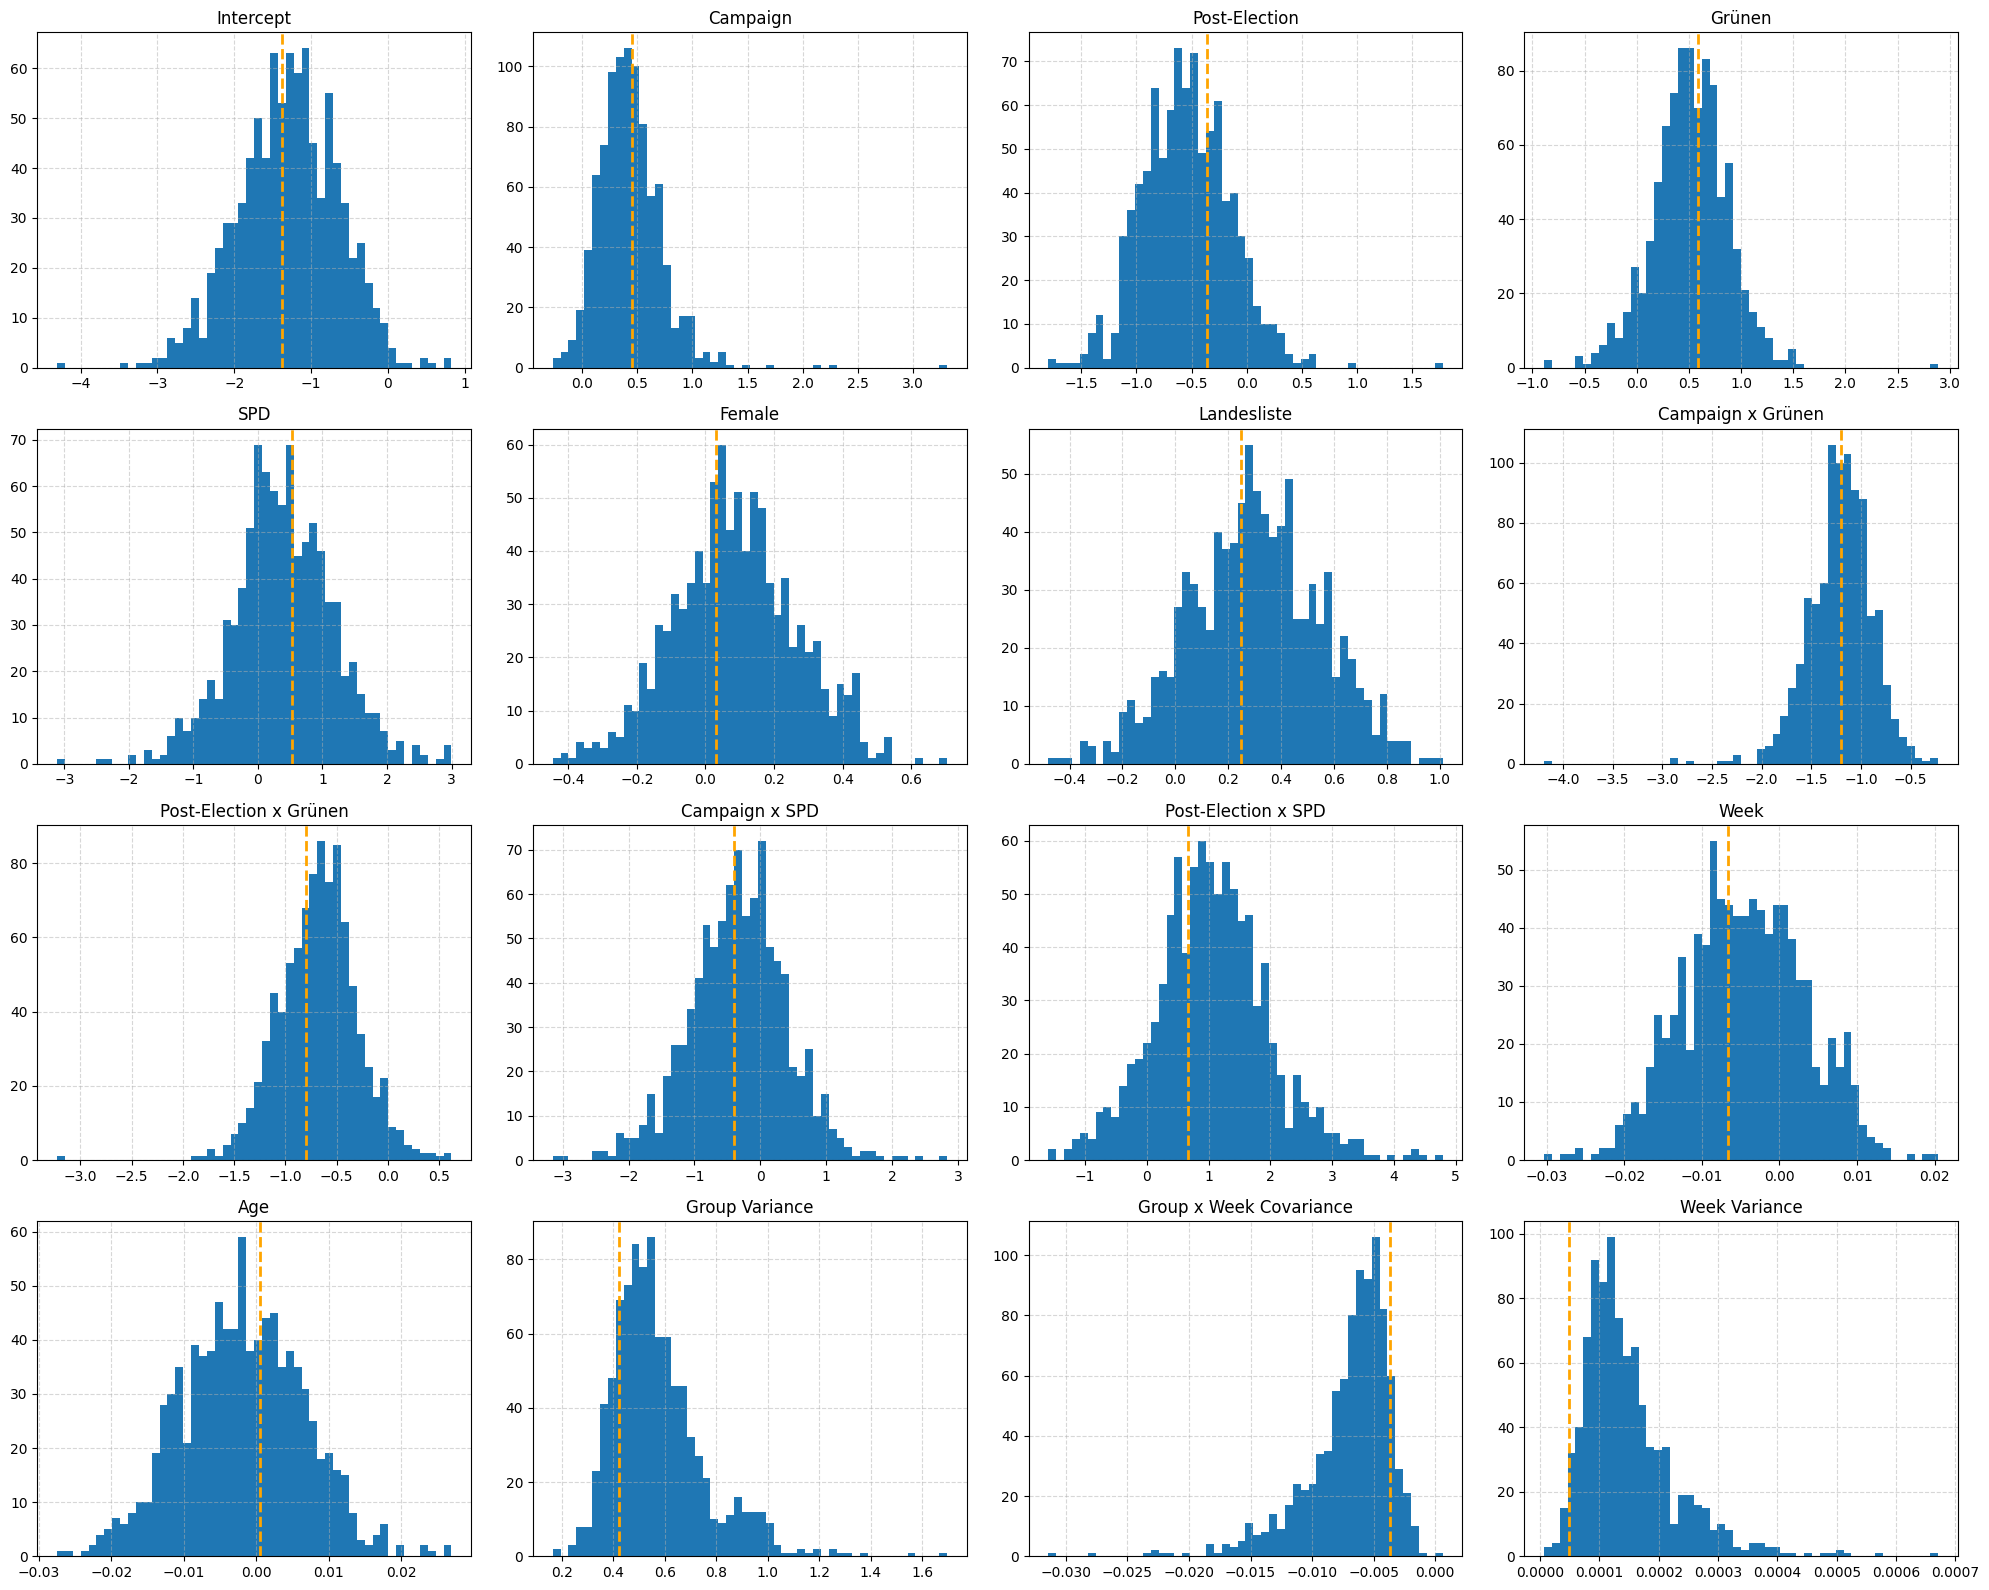

In [8]:
# create a compound plot with bootstrap histograms for all coefficients
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

# loop over coefficients and create the histogram
for i, col in enumerate(df_boot.columns):
    axes[i].hist(df_boot[col], bins=50)
    axes[i].axvline(x=original_estimates[i], color='orange', linestyle='--', linewidth=2, label='Original')
    axes[i].set_title(col)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# save and show the plot
plt.tight_layout()
plt.savefig("../02_figures_tables/bootstrap_coefficient_histograms.png", dpi=300)
plt.show()

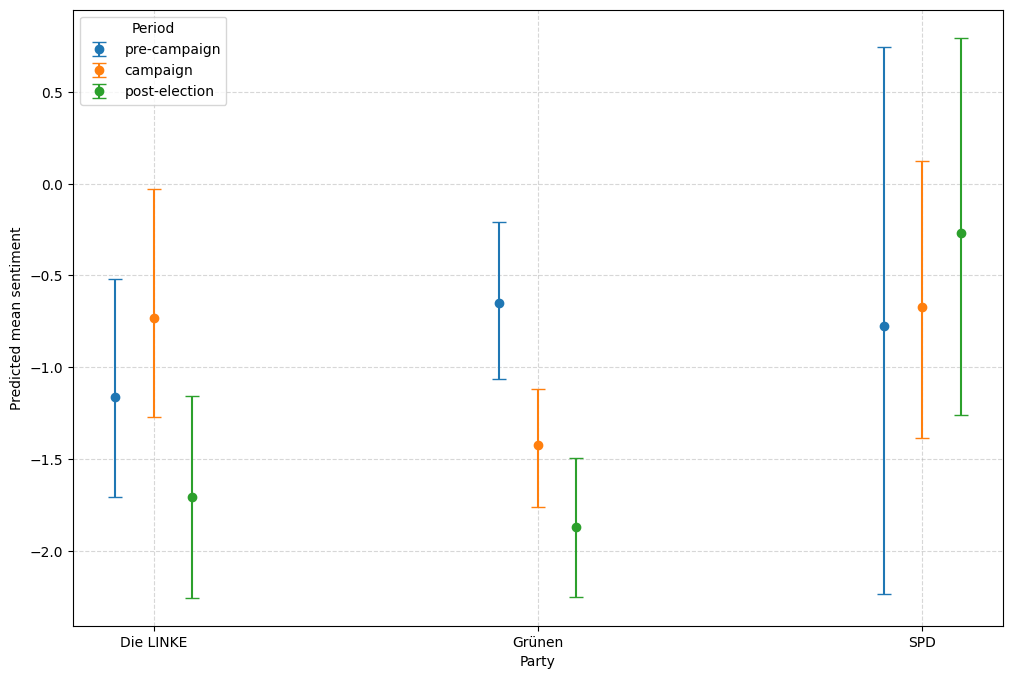

In [9]:
# create a plot with predicted sentiment for the interaction effects
plt.figure(figsize=(12,8))

# set parties as x-axis and set width between estimates
x = np.arange(len(factions))
width = 0.1

# get all distinct periods
periods_list = grid["period"].cat.categories

cmap = plt.colormaps["tab10"]
colors = [cmap(i) for i in range(len(periods_list))]

# loop over periods and subset the df for the current period
for i, period in enumerate(periods_list):
    subset = grid[grid["period"] == period]
    # plot the point estimate with errorbar for each party
    plt.errorbar(
        x + (i - (len(periods_list)-1)/2)*width,
        subset["mean"],
        yerr=[subset["mean"] - subset["ci_lower"], subset["ci_upper"] - subset["mean"]],
        fmt='o',
        capsize=5,
        color=colors[i],
        label=period
    )

# set plot labels
plt.xticks(x, factions)
plt.ylabel("Predicted mean sentiment")
plt.xlabel("Party")
plt.legend(title="Period")
plt.grid(True, linestyle="--", alpha=0.5)

# export the plot and show
plt.savefig("../02_figures_tables/interaction_effects_original.png", dpi=300)
plt.show()